# Lab Work - 2.3


In [1]:
# Common Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer, KNNImputer
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score
np.random.seed(42)

## Q1: Warm-up (Numeric Only)

In [2]:
# Create correlated data
n = 500
X = np.random.randn(n, 5)
X[:,1] = X[:,0]*0.8 + np.random.randn(n)*0.2
X[:,2] = X[:,0]*0.5 + X[:,1]*0.3 + np.random.randn(n)*0.2
df = pd.DataFrame(X, columns=[f'X{i}' for i in range(5)])

# Introduce missing
df_missing = df.copy()
for col in ['X0','X1','X2']:
    df_missing.loc[df_missing.sample(frac=0.15).index, col] = np.nan

# Impute
imp = IterativeImputer()
df_imputed = pd.DataFrame(imp.fit_transform(df_missing), columns=df.columns)

print('Before:')
print(df_missing.describe())
print('\nAfter:')
print(df_imputed.describe())

Before:
               X0          X1          X2          X3          X4
count  425.000000  425.000000  425.000000  500.000000  500.000000
mean     0.037098    0.022495    0.024945    0.012412    0.089335
std      0.971738    0.815944    0.752477    0.955087    0.999397
min     -2.703232   -2.272240   -2.137167   -2.650970   -3.019512
25%     -0.575638   -0.486086   -0.468257   -0.642849   -0.576895
50%      0.075955    0.088358    0.056808    0.033078    0.040829
75%      0.638592    0.519087    0.498012    0.658720    0.751524
max      3.193108    2.409762    2.644282    3.078881    3.852731

After:
               X0          X1          X2          X3          X4
count  500.000000  500.000000  500.000000  500.000000  500.000000
mean     0.046425    0.042008    0.035529    0.012412    0.089335
std      0.965290    0.802981    0.745767    0.955087    0.999397
min     -2.703232   -2.272240   -2.137167   -2.650970   -3.019512
25%     -0.574156   -0.476873   -0.461510   -0.642849   -0.5

## Q2: MAR Pattern + RMSE

In [3]:
# Generate data
X = np.random.randn(n,4)
X[:,3] = X[:,0]*0.7 + X[:,1]*0.3 + np.random.randn(n)*0.2
df = pd.DataFrame(X, columns=['X1','X2','X3','X4'])

# MAR missing
mask = df['X1'] < df['X1'].median()
true_values = df.loc[mask,'X4'].copy()
df.loc[mask,'X4'] = np.nan

# Impute
imp = IterativeImputer()
df_imputed = pd.DataFrame(imp.fit_transform(df), columns=df.columns)

# RMSE
rmse = np.sqrt(mean_squared_error(true_values, df_imputed.loc[mask,'X4']))
print('RMSE:', rmse)

RMSE: 0.19771949665528962


## Q3: Categorical + Numeric

In [4]:
# Mixed dataset
df = pd.DataFrame({
    'num1': np.random.randn(n),
    'num2': np.random.randn(n),
    'num3': np.random.randn(n),
    'cat1': np.random.choice(['A','B','C'], n),
    'cat2': np.random.choice(['X','Y'], n)
})

# Introduce missing
df.loc[df.sample(frac=0.2).index, 'cat1'] = np.nan

# Encode
enc = OrdinalEncoder()
df[['cat1','cat2']] = enc.fit_transform(df[['cat1','cat2']])

# Impute
imp = IterativeImputer()
df_imp = pd.DataFrame(imp.fit_transform(df), columns=df.columns)

# Round categorical
df_imp[['cat1','cat2']] = np.round(df_imp[['cat1','cat2']])

print(df_imp.head())

       num1      num2      num3  cat1  cat2
0  0.010636 -0.161235 -1.909471   1.0   1.0
1 -1.336003  0.707542  0.688387   0.0   0.0
2 -1.524147 -0.258289  0.193765   1.0   0.0
3  0.714236  0.868675 -0.191557   2.0   0.0
4 -0.422210 -0.174141  0.752700   1.0   0.0


## Q4: Estimator Sensitivity

In [5]:
estimators = {
    'BayesianRidge': BayesianRidge(),
    'RF': RandomForestRegressor(),
    'ExtraTrees': ExtraTreesRegressor()
}

results = {}
for name, est in estimators.items():
    imp = IterativeImputer(estimator=est)
    X_imp = imp.fit_transform(df_missing.select_dtypes(include=np.number))
    results[name] = np.mean(X_imp)

print(results)

c:\Users\Dell\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


{'BayesianRidge': 0.04514196100310447, 'RF': 0.04540184442843272, 'ExtraTrees': 0.04593986722649458}


c:\Users\Dell\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


## Q5: Convergence Diagnostics

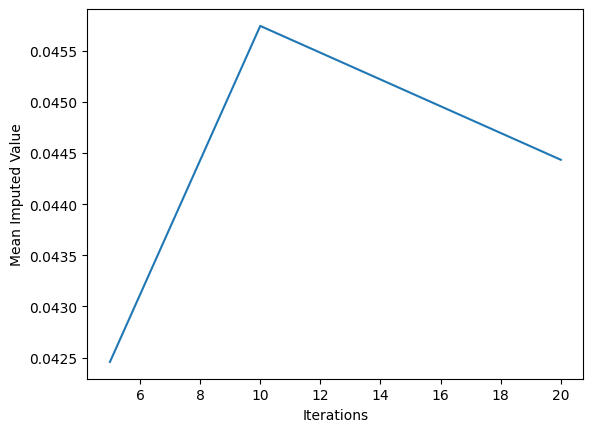

In [6]:
iters = [5,10,20]
means = []

for i in iters:
    imp = IterativeImputer(max_iter=i, sample_posterior=True)
    X_imp = imp.fit_transform(df_missing.select_dtypes(include=np.number))
    means.append(np.mean(X_imp))

plt.plot(iters, means)
plt.xlabel('Iterations')
plt.ylabel('Mean Imputed Value')
plt.show()

## Q6: Pipeline + CV

In [7]:
df['target'] = np.random.randn(n)

X = df.drop('target', axis=1)
y = df['target']

num_cols = ['num1','num2','num3']
cat_cols = ['cat1','cat2']

preprocessor = ColumnTransformer([
    ('num', IterativeImputer(), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OrdinalEncoder())
    ]), cat_cols)
])

model = Pipeline([
    ('prep', preprocessor),
    ('reg', BayesianRidge())
])

scores = cross_val_score(model, X, y, cv=5)
print('CV Score:', scores.mean())

CV Score: -0.015256116588780566


## Q7: Multiple Imputations

In [8]:
scores = []
for i in range(5):
    imp = IterativeImputer(sample_posterior=True, random_state=i)
    X_imp = imp.fit_transform(df_missing.select_dtypes(include=np.number))
    scores.append(np.mean(X_imp))

print('Mean:', np.mean(scores), 'Std:', np.std(scores))

Mean: 0.04458431185604851 Std: 0.001894185041619279


## Q8: Real Dataset Test

In [9]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing(as_frame=True)
df_real = data.frame

# Introduce missing
df_real.loc[df_real.sample(frac=0.1).index, 'MedInc'] = np.nan

# Impute
imp = IterativeImputer()
df_imp = pd.DataFrame(imp.fit_transform(df_real), columns=df_real.columns)

print(df_imp.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.869895     28.639486      5.429000      1.096675   1425.476744   
std        1.874480     12.585558      2.474173      0.473911   1132.462122   
min       -7.866037      1.000000      0.846154      0.333333      3.000000   
25%        2.576175     18.000000      4.440716      1.006079    787.000000   
50%        3.546860     29.000000      5.229129      1.048780   1166.000000   
75%        4.745956     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000